# Data Visualisation final Coursework
## Reported Road Collisions in Great Britain, 2021–2025

## Introduction


In this project, I examined the number and severity of road collisions reported to the police in Great Britain between 2021 and 2025. This is an issue of public importance, as understanding patterns related to serious and fatal collisions may help identify situations that require attention and support the development of measures to improve road safety.
Examining the number of collisions alone does not provide a complete picture, The severity matters just as much.understanding what makes an injury serious or fatal requires looking beyond raw numbers at the circumstances that surrounded each crash.The data in this project was derived from the UK Department for Transport's open data repository on road safety. The database provided  513,801 rows of reported collisions with 44 variables capturing both the conditions of each crash and the outcomes it produced. all over 5 years.

My analysis tracked five dimensions of this data. How did severity shift between 2021 and 2025? Did patterns differ by time of day or day of week? Were single-vehicle crashes more dangerous than multi-vehicle ones? Where in Great Britain did serious and fatal collisions cluster geographically? And did urban and rural areas show different injury profiles?
The aim of this project is to identify patterns and relationships through visual analysis. The analysis is not intended to predict collisions or establish causal relationships, but to present the findings, discuss their limitations and suggest possible directions for further research.

## Research  topic

RRoad collisions have public, social and economic consequences. In 2021, approximately 1.19 million people worldwide were killed in road collisions. A 5% decline from 2010 sounds good. The reality is stark, the world is nowhere near the UN's target of halving road deaths by 2030. The victims aren't only drivers and passengers, but also motorcyclists, pedestrians, and cyclists, who are a large proportion of those killed. Beyond the deaths themselves, the economic toll is enormous: 1 to 3% of GDP lost each year to collisions worldwide

This project is based on the UK Department for Transport’s STATS19 dataset, which includes injury collisions reported to the police on public roads in Great Britain. Collisions are classified as fatal, serious or slight. However, there is no legal requirement to report every injury collision, and changes in reporting methods since 2016 may affect comparisons between severity levels over time [2].

Reducing the number of collisions and reducing their severity are not necessarily the same aim, so they may require different approaches. Analysing severity is complex because it involves relationships between human, vehicle and road factors. It is also affected by underreporting and unobserved variables [3]. One characteristic that may distinguish between different severity patterns is the number of vehicles involved. Song et al. found something important, the variables that predict injury  severity are not the same for single and multiple vehicle collisions. Vehicle type matters in one scenario but not the other. Speed limit, area type, and collision location each significant in only one of the two models. This asymmetry suggests that treating all collisions together obscures important safety patterns.

These issues may affect the conclusions drawn from the data. Therefore, this project mainly presents differences and relationships between collision characteristics and severity. It also analyses the number of vehicles involved to examine this aspect in more detail. However, it does not claim that these characteristics are the sole causes of serious or fatal collisions.

Accordingly, the research examines five questions:

1. How did the number of collisions and the proportion of serious or fatal collisions change between 2021 and 2025?
2. How does this proportion vary by day of the week and hour of the day?
3. Does the proportion differ between single-vehicle and multiple-vehicle collisions?
4. 4. What geographical patterns can be observed in the distribution of serious and fatal reported road collisions?
5. How does the proportion differ between urban and rural areas?

## Data collection

The data used in this project were obtained from the UK Department for Transport’s Road Safety Open Data (STATS19) dataset [5]. The dataset contains information on road collisions involving injuries that occurred on public roads in Great Britain and were reported to the police. The dataset covers the years 2021 to 2025.
The data are collected by police forces using the same national guidelines. They are used to monitor road safety trends and help develop and evaluate road safety policies. As an official government dataset that goes through quality checks, it is suitable for examining patterns in collisions reported to the police. However, underreporting and changes in the way severity is recorded limit comparisons over time. 

## Data overview and pre-processing

Each observation in the dataset represents one reported collision. The original file contained 513,801 collisions and 44 variables.

The variables selected for the analysis include collision severity, the time of occurrence (year/day/hour), the number of vehicles involved, collision location, and the classification of the area as urban or rural. These variables were selected according to the research questions and to examine patterns over time, across locations, and in the characteristics of the collisions. Since the dataset includes only collisions reported to the police, some collisions may not be represented [2].

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
file_path = "dft-road-casualty-statistics-collision-last-5-years.csv"

#Read the ID columns as text to avoid mixed data types
Road_safety_df = pd.read_csv(file_path,dtype={
        "collision_index": "string",
        "collision_ref_no": "string"
    }
)

print("Rows:", Road_safety_df.shape[0])
print("Columns:", Road_safety_df.shape[1])
Road_safety_df.head()

Rows: 513801
Columns: 44


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517M102225,2025,17M102225,449804.0,519612.0,-1.23119,54.56929,17,3,1,...,-1,0,1,1,2,E01012092,3,1,0.0,1.0
1,202417S111924,2024,17S111924,444670.0,520502.0,-1.31046,54.57776,17,2,1,...,-1,0,1,1,2,E01012194,7,1,1.0,0.0
2,2025111687011,2025,111687011,427772.0,515144.0,-1.57237,54.53082,11,3,2,...,-1,0,1,3,2,E01035185,3,1,0.0,1.0
3,2025070326701,2025,070326701,351585.0,382993.0,-2.72862,53.34161,7,1,1,...,-1,0,1,1,2,E01012430,1,1,0.0,0.0
4,2025070353559,2025,070353559,351101.0,382954.0,-2.73589,53.34121,7,3,2,...,-1,0,1,2,2,E01012431,3,1,0.0,1.0


In [3]:
Road_safety_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 513801 entries, 0 to 513800
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   513801 non-null  string 
 1   collision_year                                    513801 non-null  int64  
 2   collision_ref_no                                  513801 non-null  string 
 3   location_easting_osgr                             513748 non-null  float64
 4   location_northing_osgr                            513748 non-null  float64
 5   longitude                                         513748 non-null  float64
 6   latitude                                          513748 non-null  float64
 7   police_force                                      513801 non-null  int64  
 8   collision_severity                                513801 non-null  int64  
 9   numb

The dataset contained 513,801 observations and 44 variables. Each observation represented one reported collision.
The date column will need to be converted to datetime format.

In [4]:
# missing values
missing_values = Road_safety_df.isna().sum()
print("missing values:")
missing_values[missing_values>0]

missing values:


location_easting_osgr     53
location_northing_osgr    53
longitude                 53
latitude                  53
dtype: int64

In [5]:
# Remove rows with missing data
Road_safety_df = Road_safety_df.dropna().copy()

print("Rows after cleaning:", Road_safety_df.shape[0])

Rows after cleaning: 513748


In [6]:
# Count duplicate collision IDs

print("Duplicate collision index:", Road_safety_df["collision_index"].duplicated().sum())

Duplicate collision index: 0


A total of 53 records contained missing location data. These records represented approximately 0.01% of the dataset, so I chose to remove them. After their removal, 513,748 observations remained. I also checked for duplicates and found no duplicate values in the collision identifier (collision_index).

In [7]:
# Check columns with object type before conversion
Road_safety_df.select_dtypes(include="object").columns.tolist()

['date',
 'time',
 'local_authority_ons_district',
 'local_authority_highway',
 'local_authority_highway_current',
 'lsoa_of_accident_location']

In [8]:
# Show the date and time columns
Road_safety_df[["date", "time"]].head(5)

,date,time
0,15/02/2025,19:15
1,22/10/2024,14:48
2,19/12/2025,06:40
3,22/04/2025,20:03
4,28/04/2025,17:40


In [9]:
# Convert the date column
Road_safety_df["date"] = pd.to_datetime(Road_safety_df["date"],dayfirst=True,errors="coerce")
Road_safety_df["date"].isna().sum()

np.int64(0)

In [10]:
# Adding an hour column
Road_safety_df["hour"] = pd.to_numeric(Road_safety_df["time"].str.split(":").str[0],errors="coerce")

In [11]:
Road_safety_df["collision_severity"].value_counts().sort_index()

collision_severity
1      7552
2    116797
3    389399
Name: count, dtype: int64

In [12]:
# collision severity label based on the "Open dataset data guide"
severity_label = {
    1: "Fatal",
    2: "Serious",
    3: "Slight"
}

Road_safety_df["collision_severity_label"] = (Road_safety_df["collision_severity"].map(severity_label))
Road_safety_df[["collision_severity","collision_severity_label"]].head(5)

,collision_severity,collision_severity_label
0,3,Slight
1,2,Serious
2,3,Slight
3,1,Fatal
4,3,Slight


The date variable was converted to a standard datetime format. 
A new variable representing the hour of the collision was created from the time variable.
The numerical collision severity codes were also replaced with clear labels: fatal, serious and slight.

In [13]:
# Summarise the main numerical variables
numeric_columns = [
    "number_of_vehicles",
    "number_of_casualties",
]

Road_safety_df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_vehicles,513748.0,1.824171,0.687805,1.0,1.0,2.0,2.0,26.0
number_of_casualties,513748.0,1.270590,0.726377,1.0,1.0,1.0,1.0,142.0


The table presents descriptive statistics for the numbers of vehicles and casualties involved in each reported collision.The average number of vehicles involved in a collision was 1.82, with a median of two vehicles. 
The average number of casualties was 1.27, with a median of one. Since both the first and third quartiles were also one, most collisions involved a single casualty. The dataset contains outliers: 26 vehicles and 142 casualties, these are exceptions.

In [14]:
#Validation of key variable values
columns_to_validate = [
    "collision_year",
    "collision_severity",
    "day_of_week",
    "hour",
    "urban_or_rural_area"
]

for column in columns_to_validate:
    values = (
        Road_safety_df[column]
        .dropna()
        .astype(int)
        .sort_values()
        .unique()
        .tolist()
    )

    print(f"{column}: {values}")

collision_year: [2021, 2022, 2023, 2024, 2025]
collision_severity: [1, 2, 3]
day_of_week: [1, 2, 3, 4, 5, 6, 7]
hour: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
urban_or_rural_area: [1, 2, 3]


Validation confirmed that the year, severity, day-of-week and hour variables contained only values within their expected ranges.

## Analysis and results

### Research Question 1 - How did the number and severity of collisions change between 2021 and 2025?

To examine changes in reported collisions from 2021 to 2025, I first calculated the total number of collisions in each year. I chose a line chart because the data are arranged chronologically and the aim was to show changes over the five-year period.

In [15]:
# Count collisions by year and severity
collisions_by_year = pd.crosstab(Road_safety_df["collision_year"],Road_safety_df["collision_severity_label"])

collisions_by_year

collision_severity_label,Fatal,Serious,Slight
collision_year,,,
2021,1473,21279,78318
2022,1602,23327,81053
2023,1522,23434,79290
2024,1502,23567,75858
2025,1453,25190,74880


In [16]:
#Genral atribute 

years = collisions_by_year.index
severity_order =["Slight", "Serious", "Fatal"]
colors = {
    "Slight": "#4C78A8",
    "Serious": "#F2A541",
    "Fatal": "#D62728"
}

day_names = {
    1: "Sunday",
    2: "Monday",
    3: "Tuesday",
    4: "Wednesday",
    5: "Thursday",
    6: "Friday",
    7: "Saturday"
}

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]


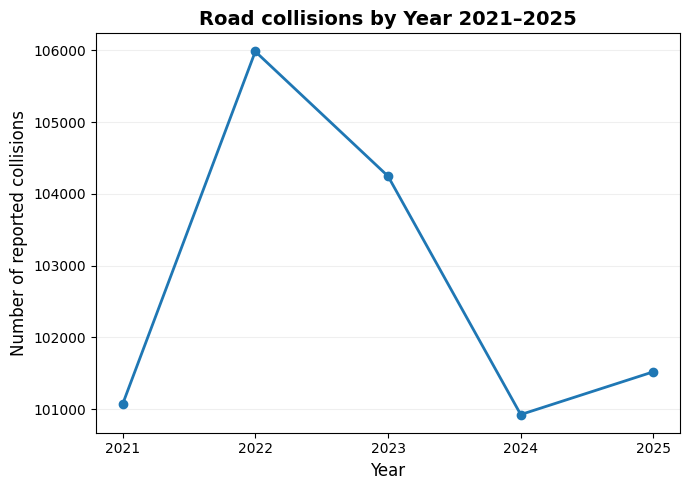

In [17]:
# Calculate the total number of collisions per year
yearly_totals = collisions_by_year.sum(axis=1)

plt.figure(figsize=(7,5))
plt.plot(
    years,
    yearly_totals.values,
    marker="o",
    linewidth=2
)

plt.title("Road collisions by Year 2021–2025", fontsize=14, fontweight="bold")

plt.xlabel("Year", fontsize=12)
plt.xticks(yearly_totals.index)

plt.ylabel("Number of reported collisions", fontsize=12)
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

The number of reported collisions changed only moderately from year to year. Since the analysis does not include vehicle mileage data and presents absolute numbers, it is not possible to determine whether these changes reflect a change in the collision rate. In addition, the narrow range of the y-axis makes the differences between years appear larger, and the five-year period is too short to identify a long-term trend.

The total number of collisions does not show whether their severity changed. I therefore calculated the proportion of fatal, serious and slight collisions in each year.I used a 100% stacked bar chart to compare the severity composition across the five years.

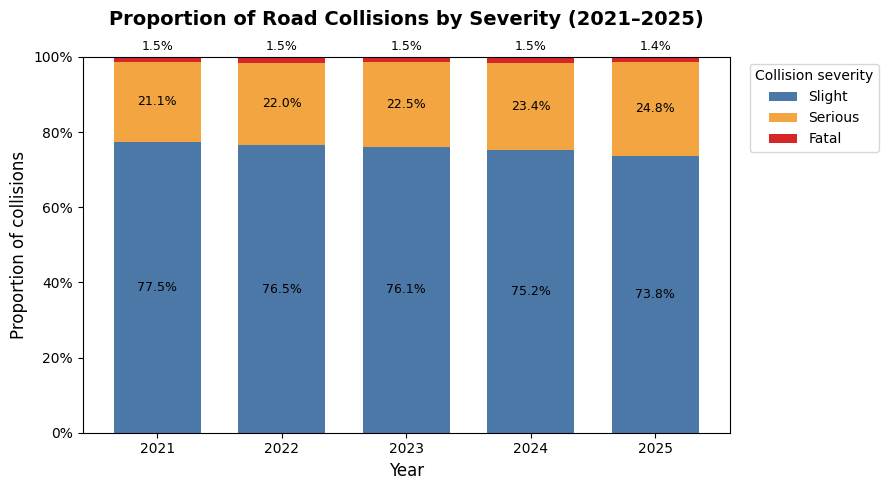

In [18]:
collisions_percent = (
    collisions_by_year
    .div(collisions_by_year.sum(axis=1), axis=0)
    .mul(100)
)

ax = collisions_percent[severity_order].plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    width=0.7,
    color = colors
)

ax.set_title("Proportion of Road Collisions by Severity (2021–2025)",fontsize=14, fontweight="bold",pad=23)

ax.set_xlabel("Year", fontsize=12)
plt.xticks(rotation=0)

ax.set_ylabel("Proportion of collisions", fontsize=12)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(100))

# percentage labels
for bars in ax.containers[:2]:
    ax.bar_label(
        bars,
        fmt="%.1f%%",
        label_type="center",
        fontsize=9,
    )
for x, value in enumerate(collisions_percent["Fatal"]):
    ax.text(
        x,
        101,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False
    )

plt.legend(
    title="Collision severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

The proportion of slight collisions gradually decreased from 77.5% in 2021 to 73.8% in 2025, while the proportion of serious collisions increased from 21.1% to 24.8%. The proportion of fatal collisions remained almost unchanged, at around 1.4%-1.5%.
Although the total number of collisions changed moderately, the severity distribution shifted towards a higher proportion of serious collisions climbed from 21.1% to 24.8% while slight collisions fell from 77.5% to 73.8%.   The graph shows the severity of reported collisions and does not measure the risk of a collision occurring.

To examine the size and direction of the changes more clearly, I calculated the percentage change in the number of collisions at each severity level relative to 2021. Using the same base year allows the three severity categories to be compared over time.

In [19]:
# Calculate the percentage change relative to 2021
pct_change_from_2021 = ((collisions_by_year - collisions_by_year.loc[2021])
    .div(collisions_by_year.loc[2021])
    .mul(100)
)

pct_change_from_2021

collision_severity_label,Fatal,Serious,Slight
collision_year,,,
2021,0.000000,0.000000,0.000000
2022,8.757637,9.624512,3.492173
2023,3.326544,10.127356,1.241094
2024,1.968771,10.752385,-3.141040
2025,-1.357773,18.379623,-4.389795


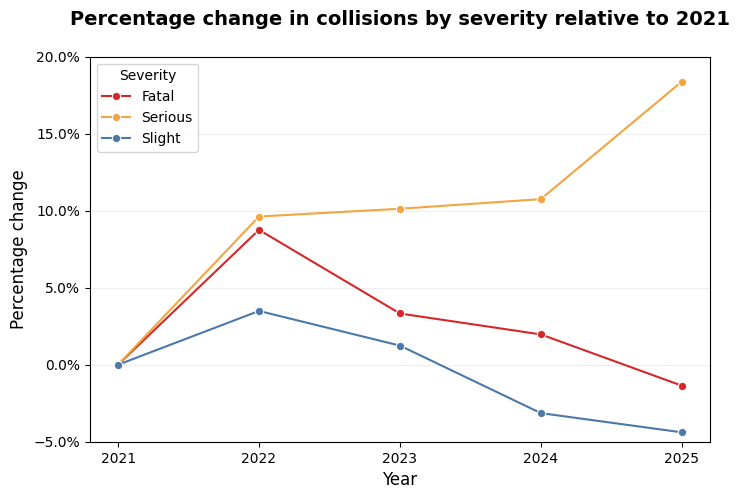

In [20]:
plt.figure(figsize=(8, 5))

p_data = pct_change_from_2021.reset_index().melt(
    id_vars="collision_year",
    var_name="Severity",
    value_name="Percentage change"
)

ax = sns.lineplot(
    data=p_data,
    x="collision_year",
    y="Percentage change",
    hue="Severity",
    palette=colors,
    marker="o"
)

ax.set_title("Percentage change in collisions by severity relative to 2021",fontsize=14, fontweight="bold",pad=23)

ax.set_xticks(years)
ax.set_xlabel("Year", fontsize=12)

ax.set_ylabel("Percentage change", fontsize=12)
ax.set_ylim(-5, 20)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(100))
plt.grid(axis="y", alpha=0.2)

plt.show()


The analysis of reported collision numbers did not show a consistent upward or downward trend between 2021 and 2025. However, the severity distribution changed over the period. The number and proportion of serious collisions increased, while the number and proportion of slight collisions decreased. By 2025, the number of serious collisions was 18.4% above the 2021 level, while the number of slight collisions was 4.4% lower.
The number of fatal collisions remained relatively stable. Therefore, the main finding is a change in the composition of collisions towards a higher proportion of serious collisions, even though the total number of collisions changed only moderately. however, the percentage changes depend on the choice of 2021 as the base year, and the fatal category contains fewer collisions than the other categories. This conclusion is based on the graphs, but it does not establish statistical significance.

### Research Question 2 - How do the number and severity of reported collisions vary by day of the week and hour of the day?

To examine how the number of reported road collisions varied across days and hours, I created a heatmap. The vertical axis shows each day, the horizontal shows hours; darker red indicates higher collision counts.The heatmap was used because it makes it easier to identify patterns across days and hours at the same time.

In [21]:
Road_safety_df.day_of_week

0         7
1         3
2         6
3         3
4         2
         ..
513796    2
513797    5
513798    5
513799    6
513800    1
Name: day_of_week, Length: 513748, dtype: int64

In [22]:
Road_safety_df["hour"].isna().sum()

np.int64(0)

In [23]:
# Count collisions by day and hour
day_hour_table = pd.crosstab(
    Road_safety_df["day_of_week"].map(day_names),
    Road_safety_df["hour"]
).reindex(
    index=day_order,
    columns=range(24),
    fill_value=0
)

day_hour_table

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,863,584,416,355,353,663,1563,3500,5491,3409,...,4454,6167,6211,6660,4821,3615,2579,2037,1583,1094
Tuesday,668,458,347,294,306,713,1593,3944,6310,3716,...,4516,6346,6773,7280,5366,3899,2692,2232,1764,1190
Wednesday,809,469,342,322,329,670,1647,3918,6304,3662,...,4551,6669,6717,7296,5820,4018,2784,2266,1919,1369
Thursday,890,546,369,306,295,693,1682,3771,6190,3766,...,4599,6729,6832,7267,5585,4263,3027,2437,2028,1471
Friday,986,621,451,406,436,712,1521,3299,5423,3454,...,5622,7670,7413,7328,6100,4840,3540,2993,2694,2352
Saturday,1813,1393,1019,800,688,670,817,1230,1912,2617,...,4860,4637,4824,5031,4656,3984,3267,2791,2776,2523
Sunday,2080,1539,1162,941,731,677,738,948,1224,1897,...,4348,3987,4125,3924,3584,3223,2599,2145,1885,1305


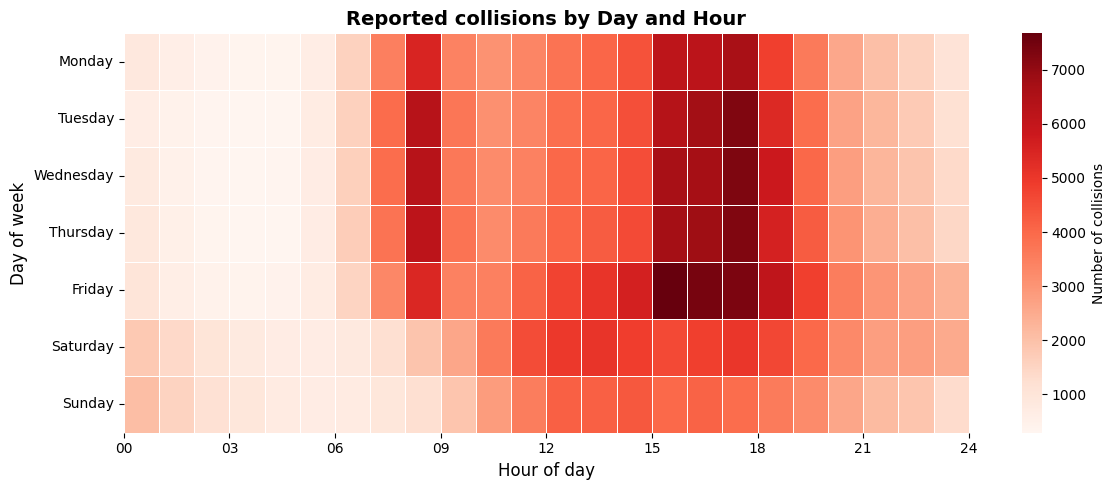

In [24]:
plt.figure(figsize=(12, 5))

ax = sns.heatmap(
    day_hour_table,
    cmap="Reds",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Number of collisions"}
)

ax.set_title("Reported collisions by Day and Hour", fontsize=14, fontweight="bold")

ax.set_xlabel("Hour of day",fontsize=12)
ax.set_xticks([0,3, 6,9, 12,15, 18,21, 24])
ax.set_xticklabels(["00", "03", "06","09", "12","15", "18","21", "24"])

ax.set_ylabel("Day of week",fontsize=12)
ax.set_yticklabels(day_order, rotation=0)

plt.tight_layout()
plt.show()

Two clear concentrations can be seen on weekdays: between 7:00 and 9:00 and between 15:00 and 18:00, with a higher concentration in the afternoon.
The highest number of collisions occurs on Friday afternoon. These patterns match the usual hours of travelling to and from work, but the dataset does not include information about the purpose of the journey, so this is only an assumption.
At weekends, the morning peak does not appear, but the number of collisions during the night and after midnight is higher than on weekdays.

The heatmap identifies when collisions were most frequent, but it does not show how their severity varied by hour. The analysis was therefore divided by severity level to examine the percentage of slight, serious and fatal collisions at each hour in relation to the overall average for each severity level. There are three separate graphs, one for each severity level, since each level has a different percentage range. Displaying all three levels together would make the smaller fatal proportion difficult to see. Bars above the overall average are shown in colour, while bars below the average are shown in grey.

In [25]:
#Analysis of collision severity rates by hour
# Calculate severity rates for each hour
hourly_severity_df = (
    Road_safety_df
    .assign(
        is_slight=Road_safety_df["collision_severity_label"] == "Slight",
        is_serious=Road_safety_df["collision_severity_label"] == "Serious",
        is_fatal=Road_safety_df["collision_severity_label"] == "Fatal"
    )
    .groupby("hour")
    .agg(
        total_collisions=("collision_index", "size"),
        slight_collisions=("is_slight", "sum"),
        serious_collisions=("is_serious", "sum"),
        fatal_collisions=("is_fatal", "sum")
    )
    .reindex(range(24), fill_value=0)
)

hourly_severity_df["slight_rate"] = (hourly_severity_df["slight_collisions"]
                                     / hourly_severity_df["total_collisions"]* 100
                                    )

hourly_severity_df["serious_rate"] = (hourly_severity_df["serious_collisions"]
                                      / hourly_severity_df["total_collisions"]* 100
                                     )

hourly_severity_df["fatal_rate"] = (hourly_severity_df["fatal_collisions"]
                                    / hourly_severity_df["total_collisions"]* 100
                                   )

hourly_severity_df

,total_collisions,slight_collisions,serious_collisions,fatal_collisions,slight_rate,serious_rate,fatal_rate
hour,,,,,,,
0,8109,5601,2245,263,69.071402,27.685288,3.243310
1,5610,3919,1510,181,69.857398,26.916221,3.226381
2,4106,2839,1120,147,69.142718,27.277155,3.580127
3,3424,2371,924,129,69.246495,26.985981,3.767523
4,3138,2174,835,129,69.279796,26.609305,4.110899
5,4798,3383,1248,167,70.508545,26.010838,3.480617
6,9561,7036,2335,190,73.590629,24.422132,1.987240
7,20610,15816,4554,240,76.739447,22.096070,1.164483
8,32854,26478,6116,260,80.592926,18.615694,0.791380


In [26]:
def hourly_severity_rate_plot(rate_column):

    rate_column_name = rate_column + "_rate"
    count_column = rate_column + "_collisions"
    
    # Weighted average
    overall_average = (
        hourly_severity_df[count_column].sum()
        / hourly_severity_df["total_collisions"].sum()
        * 100
    )

    bar_color = colors[rate_column.capitalize()]
    
    # diffrent colors for hours above the average
    bar_plot_colors = [
        bar_color if value > overall_average else "lightgrey"
        for value in hourly_severity_df[rate_column_name]
    ]

    ax = hourly_severity_df[rate_column_name].plot(
        kind="bar",
        figsize=(9, 5),
        width=0.8,
        color=bar_plot_colors
    )

    ax.axhline(
        overall_average,
        color="black",
        linewidth=1.5,
        label=f"Overall average: {overall_average:.1f}%"
    )

    ax.set_title(f"Proportion of {rate_column} collisions by hour" , fontsize=14, fontweight="bold")
    ax.set_xlabel("Hour of day",fontsize=12)
    ax.set_ylabel("Percentage of collisions",fontsize=12)
    ax.set_xticks([0,2,4,6,8,10,12,14,16,18,20,22])
    ax.set_xticklabels(["00", "02", "04","06", "08", "10", "12","14", "16", "18", "20", "22"])
    
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(100, decimals=0))
    ax.legend(loc="upper left",bbox_to_anchor=(1.02, 1))

    plt.xticks(rotation=0)
    plt.show()


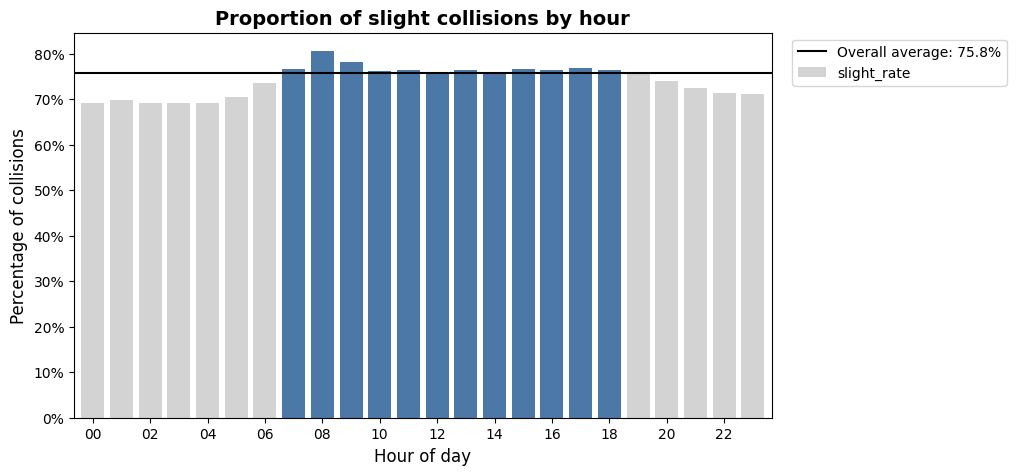

In [27]:
hourly_severity_rate_plot(
    rate_column="slight"
)

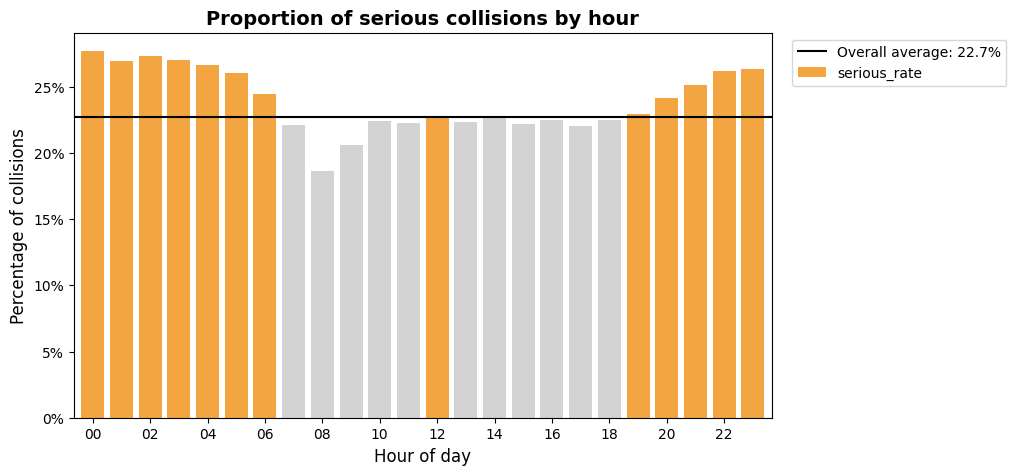

In [28]:
hourly_severity_rate_plot(
    rate_column="serious"
)

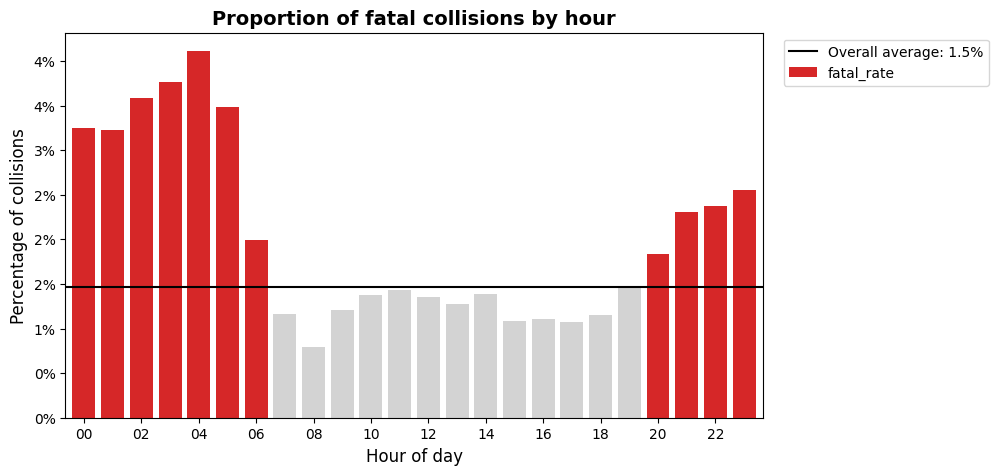

In [29]:
hourly_severity_rate_plot(
    rate_column="fatal"
)

Between 7:00 and 18:00, slight collisions clustered above the average while serious and fatal ones fell below. At night, it flipped: slight collisions dropped, and serious and fatal ones climbed. This wasn't because the night had more crashes, it had fewer. But of those few, a much larger share were severe. The graphs do not explain what causes these differences.

### Research Question 3 - Does the proportion of serious or fatal collisions differ between single-vehicle and multiple-vehicle collisions?

I examined whether the number of vehicles involved predicted injury severity. I divided the collisions into two groups: single-vehicle collisions and collisions involving multiple vehicles.

In [30]:
vehicle_df = Road_safety_df.copy()

vehicle_df["vehicle_group"] = np.where(vehicle_df["number_of_vehicles"] == 1,"Single vehicle","Multiple vehicles")

vehicle_severity = pd.crosstab(
    vehicle_df["vehicle_group"],
    vehicle_df["collision_severity_label"],
    normalize="index"
) * 100

vehicle_severity = vehicle_severity.reindex(
    index=["Single vehicle", "Multiple vehicles"],
    columns=severity_order
)

vehicle_severity

collision_severity_label,Slight,Serious,Fatal
vehicle_group,,,
Single vehicle,68.138062,29.625302,2.236636
Multiple vehicles,78.972241,19.875799,1.151961


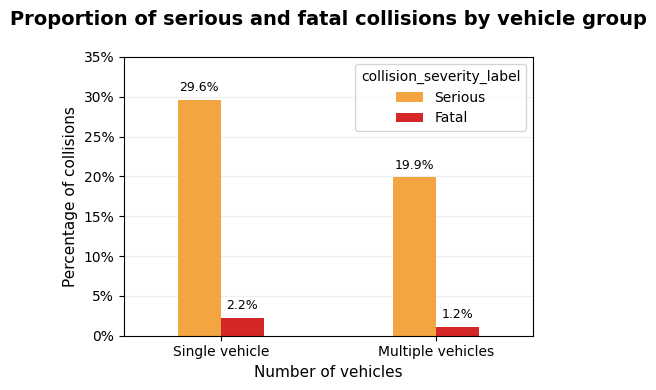

In [31]:
vehicle_severity = vehicle_severity.loc[["Single vehicle", "Multiple vehicles"],["Serious", "Fatal"]]

ax = vehicle_severity.plot(
    kind="bar",
    figsize=(5, 4),
    width=0.4,
    color=colors
)

ax.set_title("Proportion of serious and fatal collisions by vehicle group",fontsize=14,fontweight="bold",pad=23)

ax.set_xlabel("Number of vehicles", fontsize=11)
ax.set_ylabel("Percentage of collisions", fontsize=11)

ax.set_ylim(0, 35)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(100, decimals=0))

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=4,
    fontsize=9
)

ax.bar_label(
    ax.containers[1],
    fmt="%.1f%%",
    padding=4,
    fontsize=9
)

ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Among single-vehicle collisions, 29.6% were classified as serious and 2.2% as fatal. Among collisions involving multiple vehicles, the proportions were lower, with 19.9% classified as serious and 1.2% as fatal.
When the two severity levels were combined, 31.9% of single-vehicle collisions were serious or fatal, compared with 21.0% of multiple-vehicle collisions. Therefore, single-vehicle collisions had a higher proportion of serious and fatal outcomes.
The graph shows an association only and does not indicate that the involvement of a single vehicle causes greater collision severity. Other factors not examined in the analysis may explain part of this difference.

To examine whether this difference remained consistent over time, I calculated the combined proportion of serious and fatal collisions for each vehicle group in each year.

In [32]:
# KSI rate by year and vehicle group
vehicle_year_rate = pd.crosstab([vehicle_df["collision_year"],vehicle_df["vehicle_group"]],
                                vehicle_df["collision_severity_label"],
                                normalize="index"
                               ) * 100

vehicle_year_rate["serious_and_fatal_rate"] = (vehicle_year_rate["Serious"]+ vehicle_year_rate["Fatal"])

vehicle_year_rate = vehicle_year_rate.reset_index()

vehicle_year_rate = vehicle_year_rate[["collision_year", "vehicle_group", "serious_and_fatal_rate"]]

vehicle_year_rate.head(10)

collision_severity_label,collision_year,vehicle_group,serious_and_fatal_rate
0,2021,Multiple vehicles,19.359781
1,2021,Single vehicle,30.747229
2,2022,Multiple vehicles,20.266898
3,2022,Single vehicle,31.378233
4,2023,Multiple vehicles,20.507446
5,2023,Single vehicle,32.131254
6,2024,Multiple vehicles,21.751695
7,2024,Single vehicle,32.140714
8,2025,Multiple vehicles,23.373702
9,2025,Single vehicle,32.819947


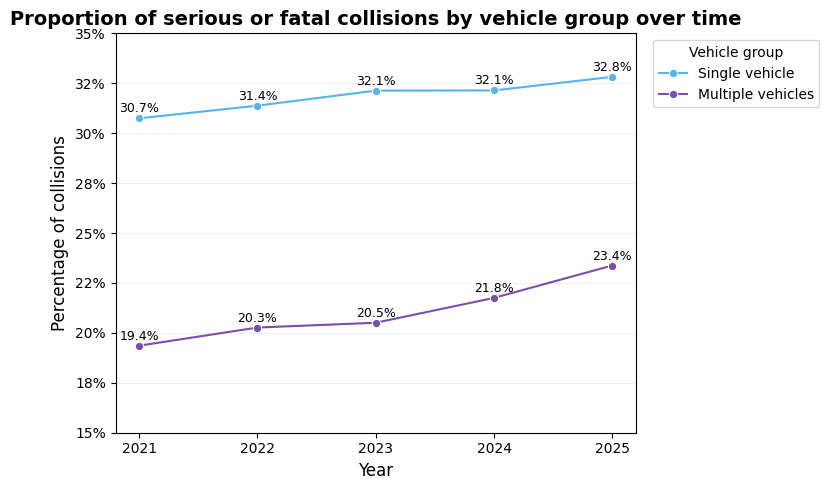

In [33]:
plt.figure(figsize=(8, 5))

ax = sns.lineplot(
    data=vehicle_year_rate,
    x="collision_year",
    y="serious_and_fatal_rate",
    hue="vehicle_group",
    hue_order=["Single vehicle", "Multiple vehicles"],
    palette={"Single vehicle": "#56B4E9","Multiple vehicles": "#7A4EAB"},
    marker="o"
)


for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.text(x,y + 0.3,f"{y:.1f}%",ha="center",fontsize=9)
        
ax.set_title("Proportion of serious or fatal collisions by vehicle group over time",fontsize=14,fontweight="bold")

ax.set_xlabel("Year", fontsize=12)
ax.set_xticks(years)


ax.set_ylabel("Percentage of collisions", fontsize=12)
ax.set_ylim(15, 35)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(100, decimals=0))

ax.legend(title="Vehicle group",bbox_to_anchor=(1.02, 1),loc="upper left")

ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()



Further analysis shows an increase in the proportion of serious or fatal collisions in both vehicle groups over the period. Among single-vehicle collisions, the proportion increased from 30.7% in 2021 to 32.8% in 2025. A larger increase was recorded among multiple-vehicle collisions, from 19.4% to 23.4%. The proportion of serious or fatal collisions remained higher among single-vehicle collisions in every year. However, the gap between the two groups narrowed slightly over the period.

### Research Question 4 - What geographical patterns can be observed in the distribution of serious and fatal reported road collisions?

To examine the geographical distribution of serious and fatal collisions, I created two point maps, one for each severity level. The geographical boundaries used in the maps were obtained from the ONS Open Geography Portal [6]. On the maps, each point represents one reported collision classified as serious or fatal between 2021 and 2025.

In [34]:
#Office for National Statistics (ONS) accessed via the ONS Open Geography Portal/data.gov.uk
map_file = "Westminster_Parliamentary_Constituencies_(December_2019)_Boundaries_UK_BUC.geojson"
gdf = gpd.read_file(map_file)

# convert the map to the same british national grid
gdf = gdf.to_crs("EPSG:27700")

# remove Northern Ireland because the collision data covers great britain only
gdf = gdf[~gdf["pcon19cd"].str.startswith("N")].copy()


severity_df = Road_safety_df[Road_safety_df["collision_severity_label"].isin(["Serious", "Fatal"])].copy()

severity_gdf = gpd.GeoDataFrame(
    severity_df,
    geometry=gpd.points_from_xy(
        severity_df["location_easting_osgr"],
        severity_df["location_northing_osgr"]
    ),
    crs="EPSG:27700"
)

display(severity_gdf.head())

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight,hour,collision_severity_label,geometry
1,202417S111924,2024,17S111924,444670.0,520502.0,-1.31046,54.57776,17,2,1,...,1,2,E01012194,7,1,1.0,0.0,14,Serious,POINT (444670 520502)
3,2025070326701,2025,070326701,351585.0,382993.0,-2.72862,53.34161,7,1,1,...,1,2,E01012430,1,1,0.0,0.0,20,Fatal,POINT (351585 382993)
6,2025070962415,2025,070962415,361512.0,386901.0,-2.58001,53.37755,7,2,1,...,1,2,E01012510,7,1,1.0,0.0,16,Serious,POINT (361512 386901)
10,2024041405411,2024,041405411,332463.0,439026.0,-3.02793,53.84307,4,2,1,...,2,2,E01012692,7,1,1.0,0.0,15,Serious,POINT (332463 439026)
15,2024161467292,2024,161467292,512098.0,430765.0,-0.30105,53.76119,16,2,2,...,1,2,E01012902,7,1,1.0,0.0,12,Serious,POINT (512098 430765)


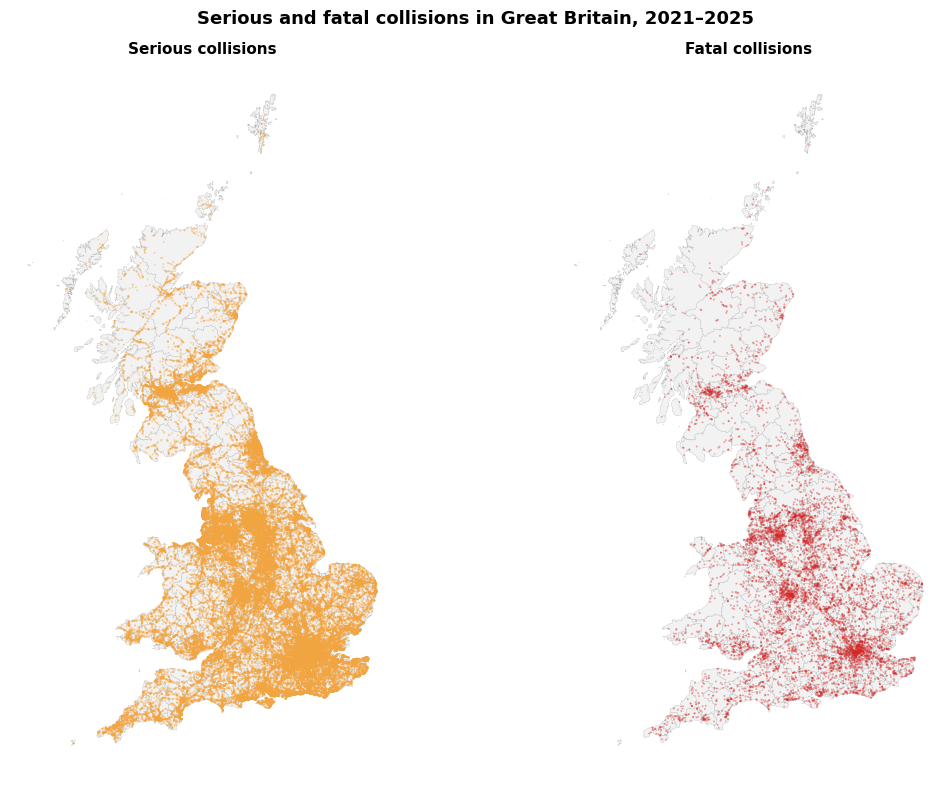

In [35]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 8)
)

# serious collisions

serious_data = severity_gdf[severity_gdf["collision_severity_label"] == "Serious"]

gdf.plot(
    ax=axes[0],
    color="#F2F2F2",
    edgecolor="#B0B0B0",
    linewidth=0.2
)

serious_data.plot(
    ax=axes[0],
    color=colors["Serious"],
    markersize=2,
    alpha=0.4,
    edgecolor="none"
)

axes[0].set_title("Serious collisions",fontsize=11,fontweight="bold")

axes[0].set_axis_off()
axes[0].set_aspect("equal")


# fatal collisions
fatal_data = severity_gdf[severity_gdf["collision_severity_label"] == "Fatal"]

gdf.plot(
    ax=axes[1],
    color="#F2F2F2",
    edgecolor="#B0B0B0",
    linewidth=0.2
)

fatal_data.plot(
    ax=axes[1],
    color=colors["Fatal"],
    markersize=2,
    alpha=0.4,
    edgecolor="none"
)

axes[1].set_title("Fatal collisions",fontsize=11,fontweight="bold")

axes[1].set_axis_off()
axes[1].set_aspect("equal")



fig.suptitle(
    "Serious and fatal collisions in Great Britain, 2021–2025",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Serious collisions were much more common than fatal collisions and were distributed across a wider road network. Both maps show clear concentrations in southern and central England. In some areas, the points form linear patterns. This may indicate that collisions are concentrated along road networks and transport routes. Fatal collisions are fewer and more scattered, but their spatial distribution is broadly similar to that of serious collisions. Rural and remote areas appear to have fewer collisions, but this does not mean that they are safer, as they may have smaller populations and fewer journeys. In areas with many collisions, points overlap and make the exact number difficult to see. The maps show distribution, not actual risk we lack traffic volume and population data.

### Research Question 5: How do the proportions of serious and fatal reported road collisions differ between urban and rural areas in Great Britain, 2021–2025?

The previous question showed where serious and fatal collisions occurred geographically. Now I examine whether urban and rural areas have different severity profiles. I calculated the proportions of serious and fatal collisions within each area type.

In [36]:
Road_safety_df["urban_or_rural_area"].value_counts().sort_index()

urban_or_rural_area
1    345314
2    168429
3         5
Name: count, dtype: int64

According to the STATS19 data guide, code 3 represents an unallocated area type. I excluded five records that had this code from the urban-rural comparison because they could not be assigned to either category.

In [37]:

urban_rural_df = Road_safety_df[Road_safety_df["urban_or_rural_area"].isin([1, 2])].copy()

urban_rural_df["area_type"] = urban_rural_df["urban_or_rural_area"].map({1: "Urban",2: "Rural"})

urban_rural_df[["urban_or_rural_area", "area_type"]].head()

,urban_or_rural_area,area_type
0,1,Urban
1,1,Urban
2,1,Urban
3,1,Urban
4,1,Urban


In [38]:
urban_rural_severity = pd.crosstab(
    urban_rural_df["area_type"],
    urban_rural_df["collision_severity_label"],
    normalize="index"
) * 100

urban_rural_severity = urban_rural_severity.loc[["Urban", "Rural"],["Serious", "Fatal"]]

urban_rural_severity

collision_severity_label,Serious,Fatal
area_type,,
Urban,20.883022,0.804775
Rural,26.529873,2.833835


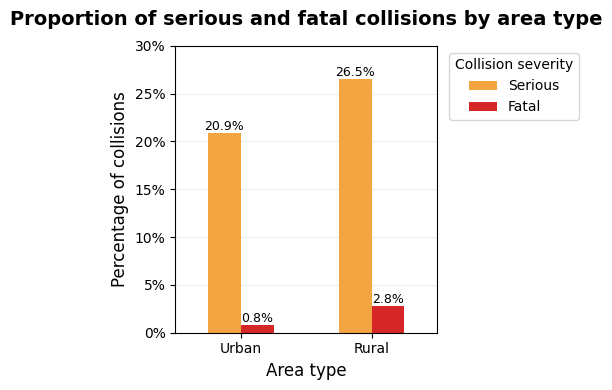

In [39]:
ax = urban_rural_severity.plot(
    kind="bar",
    figsize=(5, 4),
    width=0.5,
    color=[colors["Serious"],colors["Fatal"]]
)

ax.set_title("Proportion of serious and fatal collisions by area type",fontsize=14,fontweight="bold",pad=15)


ax.set_xlabel("Area type", fontsize=12)
ax.set_xticklabels(["Urban", "Rural"],rotation=0)

ax.set_ylabel("Percentage of collisions", fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(100, decimals=0))
ax.set_ylim(0, 30)

ax.legend(title="Collision severity",bbox_to_anchor=(1.02, 1),loc="upper left")

for c in ax.containers:
    ax.bar_label(
        c,
        fmt="%.1f%%",
        fontsize=9
    )

ax.grid(axis="y",alpha=0.2)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

The bar chart shows that rural areas had a higher proportion of collisions at both severity levels. The proportion of serious collisions was 26.5% in rural areas, compared with 20.9% in urban areas. Fatal collisions were three and a half times more common in rural areas (2.8%) than urban ones (0.8%).

To add geographical context to the comparison, I created separate point maps for serious and fatal collisions. The maps use different colours to distinguish between area types. Collisions in urban areas are shown in purple, while collisions in rural areas are shown in green. Point maps were used to show where the collisions in each area category were distributed.

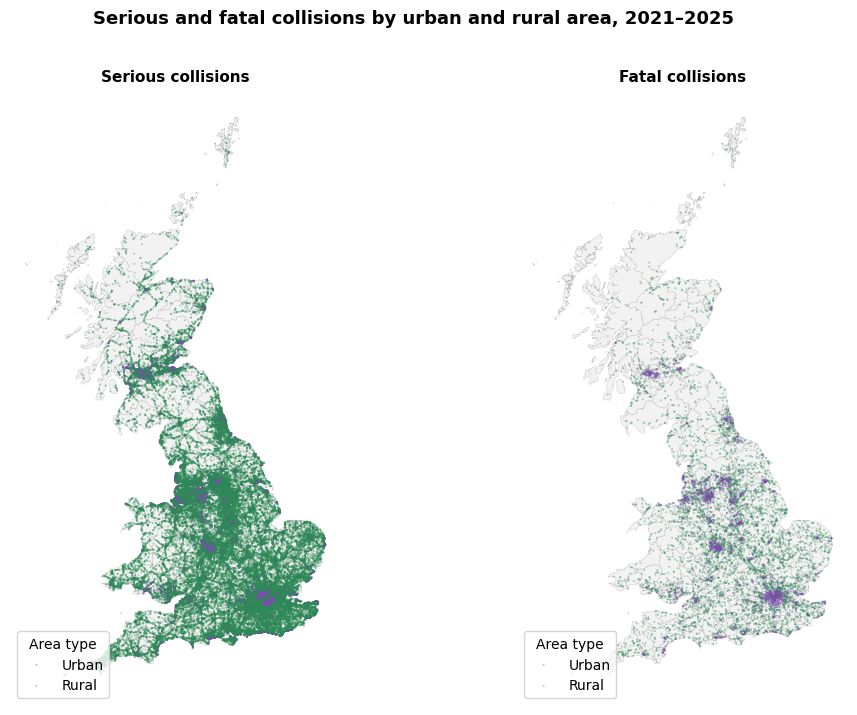

In [40]:
area_colors = {
    1: "#7A4EAB",  # Urban - purple
    2: "#2E8B57"   # Rural - green
}

fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(12, 8))

s_urban = serious_data[serious_data["urban_or_rural_area"] == 1]
s_rural = serious_data[serious_data["urban_or_rural_area"] == 2]


gdf.plot(
    ax=axes[0],
    color="#F2F2F2",
    edgecolor="#B0B0B0",
    linewidth=0.2
)

s_urban.plot(
    ax=axes[0],
    color=area_colors[1],
    markersize=2,
    alpha=0.4,
    edgecolor="none",
    label="Urban"
)

s_rural.plot(
    ax=axes[0],
    color=area_colors[2],
    markersize=2,
    alpha=0.4,
    edgecolor="none",
    label="Rural"
)


axes[0].set_title("Serious collisions",fontsize=11,fontweight="bold")

axes[0].set_axis_off()
axes[0].set_aspect("equal")
axes[0].legend(title="Area type",loc="lower left")


# fatal collisions
f_urban = fatal_data[fatal_data["urban_or_rural_area"] == 1]
f_rural = fatal_data[fatal_data["urban_or_rural_area"] == 2]


gdf.plot(
    ax=axes[1],
    color="#F2F2F2",
    edgecolor="#B0B0B0",
    linewidth=0.2
)

f_urban.plot(
    ax=axes[1],
    color=area_colors[1],
    markersize=2,
    alpha=0.4,
    edgecolor="none",
    label="Urban"
)

f_rural.plot(
    ax=axes[1],
    color=area_colors[2],
    markersize=2,
    alpha=0.4,
    edgecolor="none",
    label="Rural"
)

axes[1].set_title("Fatal collisions",fontsize=11,fontweight="bold")
axes[1].set_axis_off()
axes[1].set_aspect("equal")

axes[1].legend(title="Area type",loc="lower left")


fig.suptitle(
    "Serious and fatal collisions by urban and rural area, 2021–2025",
    fontsize=13,
    fontweight="bold"
)

plt.show()

Urban points are more concentrated in densely populated areas, while rural points are spread across a wider area. The maps and the bar chart provide different information. The maps and bar chart serve different purposes: the maps show spatial distribution, while the bar chart compares severity proportions. Overlapping points make exact location comparisons difficult, so we see distribution rather than relative risk.

## Conclusions

The project examined patterns in the number and severity of reported road collisions in Great Britain between 2021 and 2025. The total number of collisions changed moderately, with no consistent upward or downward trend. However, collision severity changed over the period. The number and proportion of serious collisions increased, while the number and proportion of slight collisions decreased. The number of fatal collisions remained relatively stable.

The analysis by time showed that the number of collisions was higher on weekdays during the morning and afternoon. There were fewer collisions at night, but a higher proportion of them were serious or fatal. Drivers may have lower concentration levels during the night. Lower traffic volumes may also allow vehicles to travel at higher speeds, which could result in more severe collisions. On the other hand, there may be more vehicles on the road during peak hours, resulting in a higher number of collisions. The analysis does not include information about traffic volume, driver concentration or actual driving speed. These explanations are therefore only assumptions.

Differences were also found according to the number of vehicles. Among single-vehicle collisions, 31.9% were serious or fatal, compared with 21.0% among multiple-vehicle collisions. This difference remained throughout the period, although the gap between the two groups narrowed slightly.

The proportion of serious and fatal collisions was also higher in rural areas. In these areas, 26.5% of collisions were serious and 2.8% were fatal, compared with 20.9% and 0.8% in urban areas. The maps showed concentrations of collisions in southern and central England, as well as patterns along transport networks. However, the maps show locations and absolute numbers rather than the relative risk in each area.

Overall, the number of collisions alone does not provide the full picture. Collision severity varied according to the hour, the number of vehicles involved and the type of area. The analysis shows relationships between these variables, but it does not prove that any of them cause more serious collisions.

Limitations of the analysis:

The analysis has several limitations. The dataset includes only collisions reported to the police, so unreported collisions are not represented. The analysis also uses the original severity classification, and changes in how police forces record injury severity may affect comparisons between years.

The dataset does not include vehicle mileage, traffic volume or population data by hour and area. Therefore, the percentages describe reported collisions but do not measure the risk of a collision occurring. Statistical significance tests were also not performed. The differences found are therefore descriptive and do not establish causality.

Further recommendation research:

For further research, I recommend adding vehicle mileage data and calculating the number of collisions per million or billion vehicle miles. This would allow comparisons between years and areas while taking the amount of travel into account.

A statistical model could also be used to examine variables such as hour, area type, number of vehicles, speed limit, lighting conditions, weather and road surface conditions together. Combinations of variables could also be examined, such as whether single-vehicle collisions at night and in rural areas are associated with a higher proportion of serious or fatal collisions.

The STATS19 vehicle and casualty files could also be used. These files could provide additional information about vehicle type, driver age and road-user type. In conclusion, road collisions are an important issue with public, social and economic effects. Further research is needed to better understand these patterns and examine ways to reduce both the number and severity of collisions. 

## Critical engagement with AI

During this project, I used artificial intelligence tools to find relevant articles, correct English wording and grammar, and help identify and fix errors in the code.
I did not accept the responses automatically. I checked the articles against the original sources, as well as the accuracy and efficiency of the suggested code solutions. The responsibility for selecting the sources and analysis methods, checking the code and results, and writing the final conclusions remains mine.

## References

[1] World Health Organization, *Global Status Report on Road Safety 2023*, 2023.  
https://www.who.int/teams/social-determinants-of-health/safety-and-mobility/global-status-report-on-road-safety-2023

[2] Department for Transport, “RRCGB 2025: Background information,” 2026.  
https://www.gov.uk/government/statistics/reported-road-casualties-great-britain-final-results-2025/rrcgb-2025-background-information

[3] P. T. Savolainen, F. L. Mannering, D. Lord, and M. A. Quddus, “The statistical analysis of highway crash-injury severities: A review and assessment of methodological alternatives,” *Accident Analysis & Prevention*, vol. 43, no. 5, pp. 1666-1676, 2011.  
https://doi.org/10.1016/j.aap.2011.03.025

[4] P. Song, N. N. Sze, J. Guo, and D. Zhu, “Temporal transferability assessment of injury severity models for single-vehicle and multi-vehicle crashes at highway ramp areas,” *Journal of Safety Research*, vol. 92, pp. 420-436, 2025.  
https://doi.org/10.1016/j.jsr.2024.12.011

[5] Department for Transport, “Road Safety Open Data,” 2026.  
https://www.gov.uk/government/statistical-data-sets/road-safety-open-data

[6] Office for National Statistics, “Westminster Parliamentary Constituencies, December 2019, Boundaries UK BUC.”  
https://www.data.gov.uk/dataset/47709c67-0d02-413f-81b7-eb2d7bdb4494/westminster-parliamentary-constituencies-december-2019-boundaries-uk-buc1

## Word Count

The following code will count the number of words in Markdown cells. Code cells are not included.

- `Main word count` is the number of words in the main body of the text, *excluding* references or appendices.
- `References and appendices word count` is the number of words in any references or appendices.

Only `Main word count` relates to the assignment word limit. There is no limit to the number of words that can be included in references or appendices. Please note that appendices should only be used to provide context or supporting information. *No marks will be directly awarded for material submitted in appendices*.

Important:

- Please do not modify the word count code!
- To exclude references from your word count **you must** have a cell that starts with the text `## References`. Everything below this cell will not count towards the main word count.
- If you are submitting additional material as appendices **you must** have a cell that starts with the text `## Appendices`. Everything below this cell will not count towards the main word count. If you do not have any appendices you can delete the `## Appendices` cell.
- Code comments should only be used to explain details of the implementation, not for discussing your findings. All analysis commentary **must** be written in Markdown cells. *No marks will be awarded for analysis discussion submitted as comments in code cells*.

In [41]:
%%js

// Run this cell to update your word count.

function wordcount() {
    let wordCount = 0
    let extraCount = 0
    let mainBody = true

    let cells = Jupyter.notebook.get_cells()
    cells.forEach((cell) => {
        if (cell.cell_type == 'markdown') {
            let text = cell.get_text()
            // Stop counting as main body when get to References or Appendices.
            if (text.startsWith('## References') ||
                text.startsWith('## Appendices')) {
                mainBody = false
            }
            if (text.startsWith('## Word Count')) {
                text = ''
            }
            if (text) {
                let words = text.toLowerCase().match(/\b[a-z\d]+\b/g)
                if (words) {
                    let cellCount = words.length
                    if (mainBody) {
                        wordCount += cellCount
                    } else {
                        extraCount += cellCount
                    }
                }
            }
        }
    })
    return [wordCount, extraCount]
}

let wc = wordcount()
element.append(`Main word count: ${wc[0]} (References and appendices word count: ${wc[1]})`)

<IPython.core.display.Javascript object>